# SentimentScope: Sentiment Analysis using Transformers!


## <a name="load-explore-and-prepare-the-dataset"></a>Load, Explore, and Prepare the Dataset

### 1. Load the Dataset


In [3]:
import os
import pandas as pd

In [4]:
# Define paths to dataset
train_pos_path = 'aclImdb/train/pos'
train_neg_path = 'aclImdb/train/neg'
test_pos_path = 'aclImdb/test/pos'
test_neg_path = 'aclImdb/test/neg'

In [5]:
def load_dataset(folder):
    """
    Reads all text files in the specified folder and returns their content as a list.

    Args:
        folder (str): Path to the folder containing text files.

    Returns:
        list: A list of strings, where each string is the content of a text file.
    """
    texts = []
    for fname in sorted(os.listdir(folder)):
        if fname.endswith('.txt'):
            with open(os.path.join(folder, fname), 'r', encoding='utf-8') as f:
                texts.append(f.read())
    return texts

In [6]:
# Load training and testing data
train_pos = load_dataset(train_pos_path)
train_neg = load_dataset(train_neg_path)
test_pos = load_dataset(test_pos_path)
test_neg = load_dataset(test_neg_path)

In [7]:
# Create DataFrames
train_df = pd.DataFrame({
    'review': train_pos + train_neg,
    'label': [1] * len(train_pos) + [0] * len(train_neg)
})

test_df = pd.DataFrame({
    'review': test_pos + test_neg,
    'label': [1] * len(test_pos) + [0] * len(test_neg)
})

print(train_df.head())

                                              review  label
0  Bromwell High is a cartoon comedy. It ran at t...      1
1  Homelessness (or Houselessness as George Carli...      1
2  Brilliant over-acting by Lesley Ann Warren. Be...      1
3  This is easily the most underrated film inn th...      1
4  This is not the typical Mel Brooks film. It wa...      1


In [8]:
# Assert that both datasets have the expected number of rows
assert train_df.shape[0] == 25000, "Training dataset does not have 25000 rows."
assert test_df.shape[0] == 25000, "Testing dataset does not have 25000 rows."

# Assert that both datasets have exactly two columns
assert train_df.shape[1] == 2, "Training dataset does not have exactly 2 columns."
assert test_df.shape[1] == 2, "Testing dataset does not have exactly 2 columns."


### 2. Explore the Dataset

In [9]:
import matplotlib.pyplot as plt

train_df.info()
print(train_df.describe(include='all'))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   review  25000 non-null  object
 1   label   25000 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 390.8+ KB
                                                   review        label
count                                               25000  25000.00000
unique                                              24904          NaN
top     This show comes up with interesting locations ...          NaN
freq                                                    3          NaN
mean                                                  NaN      0.50000
std                                                   NaN      0.50001
min                                                   NaN      0.00000
25%                                                   NaN      0.00000
50%                                                   NaN

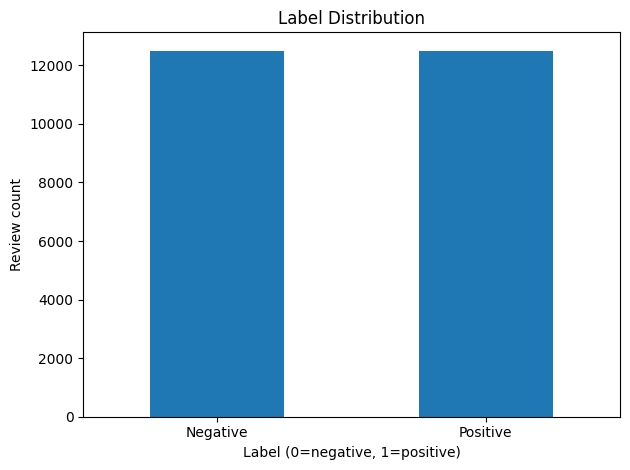

In [43]:
train_df['label'].value_counts().sort_index().plot(kind='bar')
plt.title('Label Distribution')
plt.xlabel('Label (0=negative, 1=positive)')
plt.ylabel('Review count')
plt.xticks(ticks=[0, 1], labels=['Negative', 'Positive'], rotation=0)
plt.tight_layout()
plt.savefig('label_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

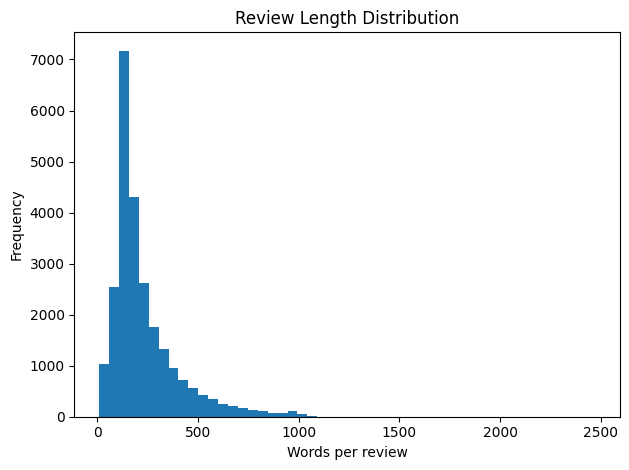

In [44]:
review_lengths = train_df['review'].str.split().str.len()
review_lengths.plot(kind='hist', bins=50)
plt.title('Review Length Distribution')
plt.xlabel('Words per review')
plt.ylabel('Frequency')
plt.tight_layout()
plt.savefig('review_length_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

In [12]:
print('Positive review sample:')
print(train_df.loc[train_df['label'] == 1, 'review'].iloc[0][:300])
print('\nNegative review sample:')
print(train_df.loc[train_df['label'] == 0, 'review'].iloc[0][:300])

Positive review sample:
Bromwell High is a cartoon comedy. It ran at the same time as some other programs about school life, such as "Teachers". My 35 years in the teaching profession lead me to believe that Bromwell High's satire is much closer to reality than is "Teachers". The scramble to survive financially, the insigh

Negative review sample:
Story of a man who has unnatural feelings for a pig. Starts out with a opening scene that is a terrific example of absurd comedy. A formal orchestra audience is turned into an insane, violent mob by the crazy chantings of it's singers. Unfortunately it stays absurd the WHOLE time with no general nar


### 3. Prepare the Dataset

In [13]:
# Split train data into training and validation sets manually
train_size = int(0.9 * len(train_df))
# Shuffle the dataset
shuffled_df = train_df.sample(frac=1, random_state=42).reset_index(drop=True)
train_data = shuffled_df.iloc[:train_size]
val_data = shuffled_df.iloc[train_size:]

### 4. Testing the Tokenizer

In [14]:
from transformers import AutoTokenizer

# Initialize tokenizer
tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

In [15]:
# Take sample inputs from the dataset
sample_texts = train_data['review'].sample(3, random_state=42).tolist()

# Tokenize sample inputs
tokenized_samples = tokenizer(sample_texts, truncation=True, padding="max_length", max_length=128, return_tensors="pt")

In [16]:
print(tokenized_samples)

{'input_ids': tensor([[  101,  2348,  1996,  3185,  2003,  4415,  6052,  1010,  9501,  2064,
          2145,  4089,  6709,  2007,  1996, 24525,  1997,  5292, 21112,  2015,
         18396,  1999,  2023, 27768,  1998,  2200,  6057,  2104, 16168,  6925,
          1012, 18396,  9590,  2114,  4895, 18824,  2135, 10238,  1999,  2093,
          2367,  5535,  1024,  1996,  2962,  2287,  1010,  1996,  3142,  2287,
          1010,  1998,  1996,  5549,  2078,  2287,  1010,  2652,  2471,  1996,
          2168,  2839,  2007,  2074,  1037,  2689,  1997, 17363,  2000,  2393,
          2149,  6709,  1996,  2367,  1000,  5535,  1000,  1012,  1999,  2023,
          3185,  2057,  2156,  2028,  1997,  1996,  5700, 21699, 20818,  1997,
          1996,  1000,  5430,  2386,  1000, 12991, 13874,  1010,  2040,  5222,
          2010,  2293,  2025,  2011,  7472,  2021,  2011, 26128,  2486,  1010,
          2004,  2092,  2004,  1037,  6057,  9792,  2006,  3142,  5580,  2401,
         29469,  2389,  4337,  1010,  

# Implement a DataLoader in PyTorch<a id="implement-a-dataloader-in-pytorch"></a>


In [17]:
import torch
from torch.utils.data import Dataset
MAX_LENGTH = 128

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [18]:
from torch.utils.data import Dataset

class IMDBDataset(Dataset):
    """
    A custom PyTorch Dataset for the IMDB dataset.

    This class preprocesses text data using a tokenizer and returns tokenized inputs
    along with their corresponding labels for sentiment analysis.

    Attributes:
        data (pd.DataFrame): A DataFrame containing text and label columns.
        tokenizer (transformers.PreTrainedTokenizer): The tokenizer used for preprocessing text.
        max_length (int): Maximum length for tokenized sequences.
    """
    def __init__(self, data, tokenizer, max_length=MAX_LENGTH):
        """
        Initialize the dataset.

        Args:
            data (pd.DataFrame): A DataFrame with columns `review` (text) and `label` (target).
            tokenizer (transformers.PreTrainedTokenizer): The tokenizer to preprocess the text.
            max_length (int, optional): Maximum token sequence length. Defaults to 128.
        """
        self.reviews = data['review'].tolist()
        self.labels = data['label'].tolist()
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        """
        Return the total number of samples in the dataset.

        Returns:
            int: Number of samples.
        """
        return len(self.reviews)

    def __getitem__(self, idx):
        """
        Retrieve a single data point by index and preprocess it.

        Args:
            idx (int): Index of the data point to retrieve.

        Returns:
            torch.Tensor: Tokenized input IDs for the text.
            int: Label corresponding to the text.
        """
        enc = self.tokenizer(
            self.reviews[idx],
            truncation=True,
            padding='max_length',
            max_length=self.max_length,
            return_tensors='pt'
        )
        return enc['input_ids'].squeeze(0), int(self.labels[idx])

### 2. Initialize the Dataset

In [19]:
# Initialize the datasets
train_dataset = IMDBDataset(train_data, tokenizer)
val_dataset = IMDBDataset(val_data, tokenizer)
test_dataset = IMDBDataset(test_df, tokenizer)

### 3. Create a DataLoader

In [20]:
from torch.utils.data import DataLoader

# Define batch size
BATCH_SIZE = 32

# Create DataLoader instances
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

In [21]:
assert len(train_dataset) == 22500, "Train dataset length mismatch!"
assert len(val_dataset) == 2500, "Validation dataset length mismatch!"
assert len(test_dataset) == 25000, "Test dataset length mismatch!"

import numpy as np

# Check the first item in the train dataset
input_ids, label = train_dataset[0]
assert isinstance(input_ids, torch.Tensor), "Input IDs should be a torch.Tensor!"
assert isinstance(label, (int, np.integer)), "Label should be an integer or int-like!"

# Ensure the input IDs tensor has the correct shape
assert input_ids.shape[0] == train_dataset.max_length, "Input IDs tensor has incorrect length!"

## <a id="customize-the-transformer-architecture"></a>Customize the Transformer Architecture

In [22]:
config = {
    "vocabulary_size": tokenizer.vocab_size,  # e.g., ~30522 for bert-base-uncased
    "num_classes": 2,                         # binary classification (pos/neg)
    "d_embed": 128,
    "context_size": MAX_LENGTH,
    "layers_num": 4,
    "heads_num": 4,
    "head_size": 32,  # 4 heads * 32 = 128 -> matches d_embed
    "dropout_rate": 0.1,
    "use_bias": True
}


### 2. Class Definitions

In [23]:
import torch.nn as nn
import math

class AttentionHead(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.Q_weights = nn.Linear(config["d_embed"], config["head_size"], bias=config["use_bias"])
        self.K_weights = nn.Linear(config["d_embed"], config["head_size"], bias=config["use_bias"])
        self.V_weights = nn.Linear(config["d_embed"], config["head_size"], bias=config["use_bias"])

        self.dropout = nn.Dropout(config["dropout_rate"])

    def forward(self, input):
        batch_size, tokens_num, d_embed = input.shape
        Q = self.Q_weights(input)  # (B, T, head_size)
        K = self.K_weights(input)  # (B, T, head_size)
        V = self.V_weights(input)  # (B, T, head_size)

        # Q @ K^T => (B, T, T)
        attention_scores = Q @ K.transpose(1, 2)

        attention_scores = attention_scores / math.sqrt(K.shape[-1])
        attention_scores = torch.softmax(attention_scores, dim=-1)
        attention_scores = self.dropout(attention_scores)

        return attention_scores @ V

In [26]:
device = torch.device("cpu")

attention_head = AttentionHead(config).to(device)

dummy_input = torch.randn(
    BATCH_SIZE,
    config["context_size"],
    config["d_embed"]
).to(device)

attention_output = attention_head(dummy_input)

print(attention_output.shape)

torch.Size([32, 128, 32])


In [27]:
class MultiHeadAttention(nn.Module):
    def __init__(self, config):
        super().__init__()
        heads_list = [AttentionHead(config) for _ in range(config["heads_num"])]
        self.heads = nn.ModuleList(heads_list)

        self.linear = nn.Linear(config["heads_num"] * config["head_size"], config["d_embed"])
        self.dropout = nn.Dropout(config["dropout_rate"])

    def forward(self, input):
        heads_outputs = [head(input) for head in self.heads]
        x = torch.cat(heads_outputs, dim=-1)  # (B, T, heads_num * head_size)
        x = self.linear(x)                   # (B, T, d_embed)
        x = self.dropout(x)
        return x

In [28]:
# Instantiate MultiHeadAttention
multi_head_attention = MultiHeadAttention(config).to(device)

# Same dummy input: (32, 128, 128)
dummy_input = torch.randn(BATCH_SIZE, config["context_size"], config["d_embed"]).to(device)

# Forward pass
mha_output = multi_head_attention(dummy_input)
print("MultiHeadAttention output shape:", mha_output.shape)

MultiHeadAttention output shape: torch.Size([32, 128, 128])


In [29]:
class FeedForward(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.linear_layers = nn.Sequential(
            nn.Linear(config["d_embed"], 4 * config["d_embed"]),
            nn.GELU(),
            nn.Linear(4 * config["d_embed"], config["d_embed"]),
            nn.Dropout(config["dropout_rate"])
        )

    def forward(self, input):
        return self.linear_layers(input)

In [30]:
# Instantiate FeedForward
feed_forward = FeedForward(config).to(device)

# Dummy input: (32, 128, 128)
dummy_input = torch.randn(BATCH_SIZE, config["context_size"], config["d_embed"]).to(device)

# Forward pass
ff_output = feed_forward(dummy_input)
print("FeedForward output shape:", ff_output.shape)

FeedForward output shape: torch.Size([32, 128, 128])


In [31]:
class Block(nn.Module):
    def __init__(self, config):
        super().__init__()

        self.multi_head = MultiHeadAttention(config)
        self.layer_norm_1 = nn.LayerNorm(config["d_embed"])

        self.feed_forward = FeedForward(config)
        self.layer_norm_2 = nn.LayerNorm(config["d_embed"])

    def forward(self, input):
        x = input
        x = x + self.multi_head(self.layer_norm_1(x))
        x = x + self.feed_forward(self.layer_norm_2(x))
        return x

In [32]:
# Instantiate a single Block
block = Block(config).to(device)

# Dummy input: (32, 128, 128)
dummy_input = torch.randn(BATCH_SIZE, config["context_size"], config["d_embed"]).to(device)

# Forward pass
block_output = block(dummy_input)
print("Block output shape:", block_output.shape)

Block output shape: torch.Size([32, 128, 128])


In [33]:
class DemoGPT(nn.Module):
    def __init__(self, config):
        """
        Initialize the DemoGPT class with configuration parameters.

        Args:
        - config (dict): Configuration dictionary with the following keys:
            - "vocabulary_size": Size of the vocabulary.
            - "d_embed": Dimensionality of the embedding vectors.
            - "context_size": Maximum sequence length (context size).
            - "layers_num": Number of transformer layers.
            - "num_classes": Number of output classes (2 for binary classification).
        """
        super().__init__()
        # Token embedding layer: Maps token indices to embedding vectors.
        self.token_embedding_layer = nn.Embedding(config["vocabulary_size"], config["d_embed"])
        
        # Positional embedding layer: Adds positional information to the embeddings.
        self.positional_embedding_layer = nn.Embedding(config["context_size"], config["d_embed"])
        
        # Transformer layers: Stacked sequence of transformer blocks.
        blocks = [Block(config) for _ in range(config["layers_num"])]
        self.layers = nn.Sequential(*blocks)
        
        # Layer normalization: Applied to stabilize training.
        self.layer_norm = nn.LayerNorm(config["d_embed"])
        
        self.classifier = nn.Linear(config["d_embed"], config["num_classes"], bias=False)

    def forward(self, token_ids):
        """
        Forward pass of the model.

        Args:
        - token_ids (torch.Tensor): Input token indices of shape (B, T), 
                                    where B is the batch size, and T is the sequence length.
        
        Returns:
        - logits (torch.Tensor): Output logits of shape (B, num_classes).
        """
        batch_size, tokens_num = token_ids.shape

        # Step 1: Create embeddings for tokens and their positions
        x = self.token_embedding_layer(token_ids)  # Shape: (B, T, d_embed)
        positions = torch.arange(tokens_num, device=token_ids.device)  # Shape: (T,)
        pos_embed = self.positional_embedding_layer(positions)  # Shape: (T, d_embed)
        x = x + pos_embed.unsqueeze(0)  # Add positional embeddings to token embeddings
        
        # Step 2: Pass embeddings through transformer layers
        x = self.layers(x)  # Shape: (B, T, d_embed)
        x = self.layer_norm(x)  # Normalize across the feature dimension
        
        x = torch.mean(x, dim=1)  # Shape: (B, d_embed)
        logits = self.classifier(x)  # Shape: (B, num_classes)
        
        return logits

In [34]:
# Instantiate the model
demo_gpt = DemoGPT(config).to(device)

# Suppose we have a batch of size 32, each with a sequence length of 128
dummy_token_ids = torch.randint(
    0, config["vocabulary_size"], 
    (BATCH_SIZE, config["context_size"])
).to(device)

# Forward pass
logits = demo_gpt(dummy_token_ids)

print("DemoGPT output shape:", logits.shape)
print("Logits sample:\n", logits[:2])  # Print first two examples' logits

DemoGPT output shape: torch.Size([32, 2])
Logits sample:
 tensor([[-0.0116,  0.0361],
        [ 0.0049,  0.0823]], grad_fn=<SliceBackward0>)


In [35]:
# Assert that the number of logits matches the number of classes
assert logits.size(1) == config["num_classes"], (
    f"Expected number of classes {config['num_classes']}, "
    f"but got {logits.size(1)}"
)

# Assert that the batch size of the output matches the input batch size
assert logits.size(0) == BATCH_SIZE, (
    f"Expected batch size {BATCH_SIZE}, "
    f"but got {logits.size(0)}"
)

## Implement Accuracy Calculation Method <a name="implement-accuracy-calculation-method"></a>

In [36]:
def calculate_accuracy(model, data_loader, device):
    """
    Calculate the accuracy of the model on the validation dataset.

    Args:
        model (torch.nn.Module): The trained transformer model.
        data_loader (torch.utils.data.DataLoader): DataLoader for the validation dataset.
        device (torch.device): Device to run the model (e.g., 'cuda' or 'cpu').

    Returns:
        float: Validation accuracy as a percentage.
    """

    model.eval()
    total_correct = 0
    total_samples = 0
    with torch.no_grad():
        for input_ids, labels in data_loader:
            input_ids = input_ids.to(device)
            labels = labels.to(device)
            predictions = torch.argmax(model(input_ids), dim=1)
            total_correct += (predictions == labels).sum().item()
            total_samples += labels.size(0)

    accuracy = (total_correct / total_samples) * 100
    return accuracy

In [37]:
model = DemoGPT(config).to(device)

In [38]:
validation_accuracy = calculate_accuracy(model, val_loader, device)
print(f"Validation Accuracy: {validation_accuracy:.2f}%")

Validation Accuracy: 50.88%


## Train the Model <a name="train-the-model"></a>


In [40]:
import torch
import torch.nn as nn
import torch.optim as optim

# ============================================================
# 1. DEVICE
# ============================================================

# Force CPU — do not use CUDA
device = torch.device("cpu")

print("Device:", device)


# ============================================================
# 2. TRAINING PARAMETERS
# ============================================================

EPOCHS = 5
LEARNING_RATE = 3e-4


# ============================================================
# 3. INITIALIZE MODEL
# ============================================================

model = DemoGPT(config).to(device)

criterion = nn.CrossEntropyLoss()

optimizer = optim.AdamW(
    model.parameters(),
    lr=LEARNING_RATE
)

print("Model device:", next(model.parameters()).device)


# ============================================================
# 4. TRAINING LOOP
# ============================================================

for epoch in range(EPOCHS):

    model.train()

    running_loss = 0.0

    for step, (input_ids, labels) in enumerate(train_loader):

        # ----------------------------------------------------
        # Move input and labels to CPU
        # ----------------------------------------------------

        input_ids = input_ids.to(device)
        labels = labels.to(device)

        # ----------------------------------------------------
        # Clear previous gradients
        # ----------------------------------------------------

        optimizer.zero_grad()

        # ----------------------------------------------------
        # Forward pass
        # ----------------------------------------------------

        logits = model(input_ids)

        # ----------------------------------------------------
        # Calculate loss
        # ----------------------------------------------------

        loss = criterion(logits, labels)

        # ----------------------------------------------------
        # Backpropagation
        # ----------------------------------------------------

        loss.backward()

        # ----------------------------------------------------
        # Update model parameters
        # ----------------------------------------------------

        optimizer.step()

        # ----------------------------------------------------
        # Track loss
        # ----------------------------------------------------

        running_loss += loss.item()

        # ----------------------------------------------------
        # Print every 100 steps
        # ----------------------------------------------------

        if (step + 1) % 100 == 0:

            average_loss = running_loss / 100

            print(
                f"Epoch [{epoch + 1}/{EPOCHS}], "
                f"Step [{step + 1}/{len(train_loader)}], "
                f"Loss: {average_loss:.4f}"
            )

            running_loss = 0.0

    # ========================================================
    # 5. VALIDATION
    # ========================================================

    val_accuracy = calculate_accuracy(
        model,
        val_loader,
        device
    )

    print(
        f"Epoch {epoch + 1}/{EPOCHS} "
        f"- Validation Accuracy: {val_accuracy:.2f}%"
    )

    print("-" * 60)


# ============================================================
# 6. FINAL STATUS
# ============================================================

print("Training completed.")
print("Final model device:", next(model.parameters()).device)

Device: cpu
Model device: cpu
Epoch [1/5], Step [100/704], Loss: 0.6815
Epoch [1/5], Step [200/704], Loss: 0.6396
Epoch [1/5], Step [300/704], Loss: 0.6176
Epoch [1/5], Step [400/704], Loss: 0.5858
Epoch [1/5], Step [500/704], Loss: 0.5989
Epoch [1/5], Step [600/704], Loss: 0.5635
Epoch [1/5], Step [700/704], Loss: 0.5416
Epoch 1/5 - Validation Accuracy: 73.36%
------------------------------------------------------------
Epoch [2/5], Step [100/704], Loss: 0.5089
Epoch [2/5], Step [200/704], Loss: 0.4966
Epoch [2/5], Step [300/704], Loss: 0.4798
Epoch [2/5], Step [400/704], Loss: 0.4743
Epoch [2/5], Step [500/704], Loss: 0.4863
Epoch [2/5], Step [600/704], Loss: 0.4615
Epoch [2/5], Step [700/704], Loss: 0.4822
Epoch 2/5 - Validation Accuracy: 77.12%
------------------------------------------------------------
Epoch [3/5], Step [100/704], Loss: 0.4295
Epoch [3/5], Step [200/704], Loss: 0.4201
Epoch [3/5], Step [300/704], Loss: 0.4122
Epoch [3/5], Step [400/704], Loss: 0.4211
Epoch [3/5],

## Test the Model <a name="test-the-model"></a>

In [41]:
test_accuracy = calculate_accuracy(model, test_loader, device)
print(f'Test Accuracy: {test_accuracy:.2f}%')
assert test_accuracy > 75, 'Test accuracy did not exceed 75%.'

torch.save(model.state_dict(), 'sentimentscope.pt')

def predict(texts, model, tokenizer, device):
    model.eval()
    enc = tokenizer(
        texts,
        truncation=True,
        padding='max_length',
        max_length=MAX_LENGTH,
        return_tensors='pt'
    )
    with torch.no_grad():
        probabilities = torch.softmax(model(enc['input_ids'].to(device)), dim=1)
    return [
        ('positive' if prob[1] > prob[0] else 'negative', prob.max().item())
        for prob in probabilities
    ]

print(predict(['Loved every moment!', 'A waste of time.'], model, tokenizer, device))

Test Accuracy: 78.51%
[('positive', 0.9961172342300415), ('negative', 0.9970364570617676)]


In [42]:
prediction_texts = ['Loved every moment!', 'A waste of time.']
prediction_results = predict(prediction_texts, model, tokenizer, device)

predictions_df = pd.DataFrame({
    'review': prediction_texts,
    'sentiment': [sentiment for sentiment, confidence in prediction_results],
    'confidence': [confidence for sentiment, confidence in prediction_results]
})
predictions_df.to_csv('sentiment_predictions.csv', index=False)
print('Saved predictions to sentiment_predictions.csv')
predictions_df

Saved predictions to sentiment_predictions.csv


,review,sentiment,confidence
0,Loved every moment!,positive,0.996117
1,A waste of time.,negative,0.997036
